🚀 正在下载 Version 2 数据集...
✅ Version 2 路径校准完成！
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rehab_data_v2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rehab_pose_v2_final, nbs=64, nms=False, opset=None,

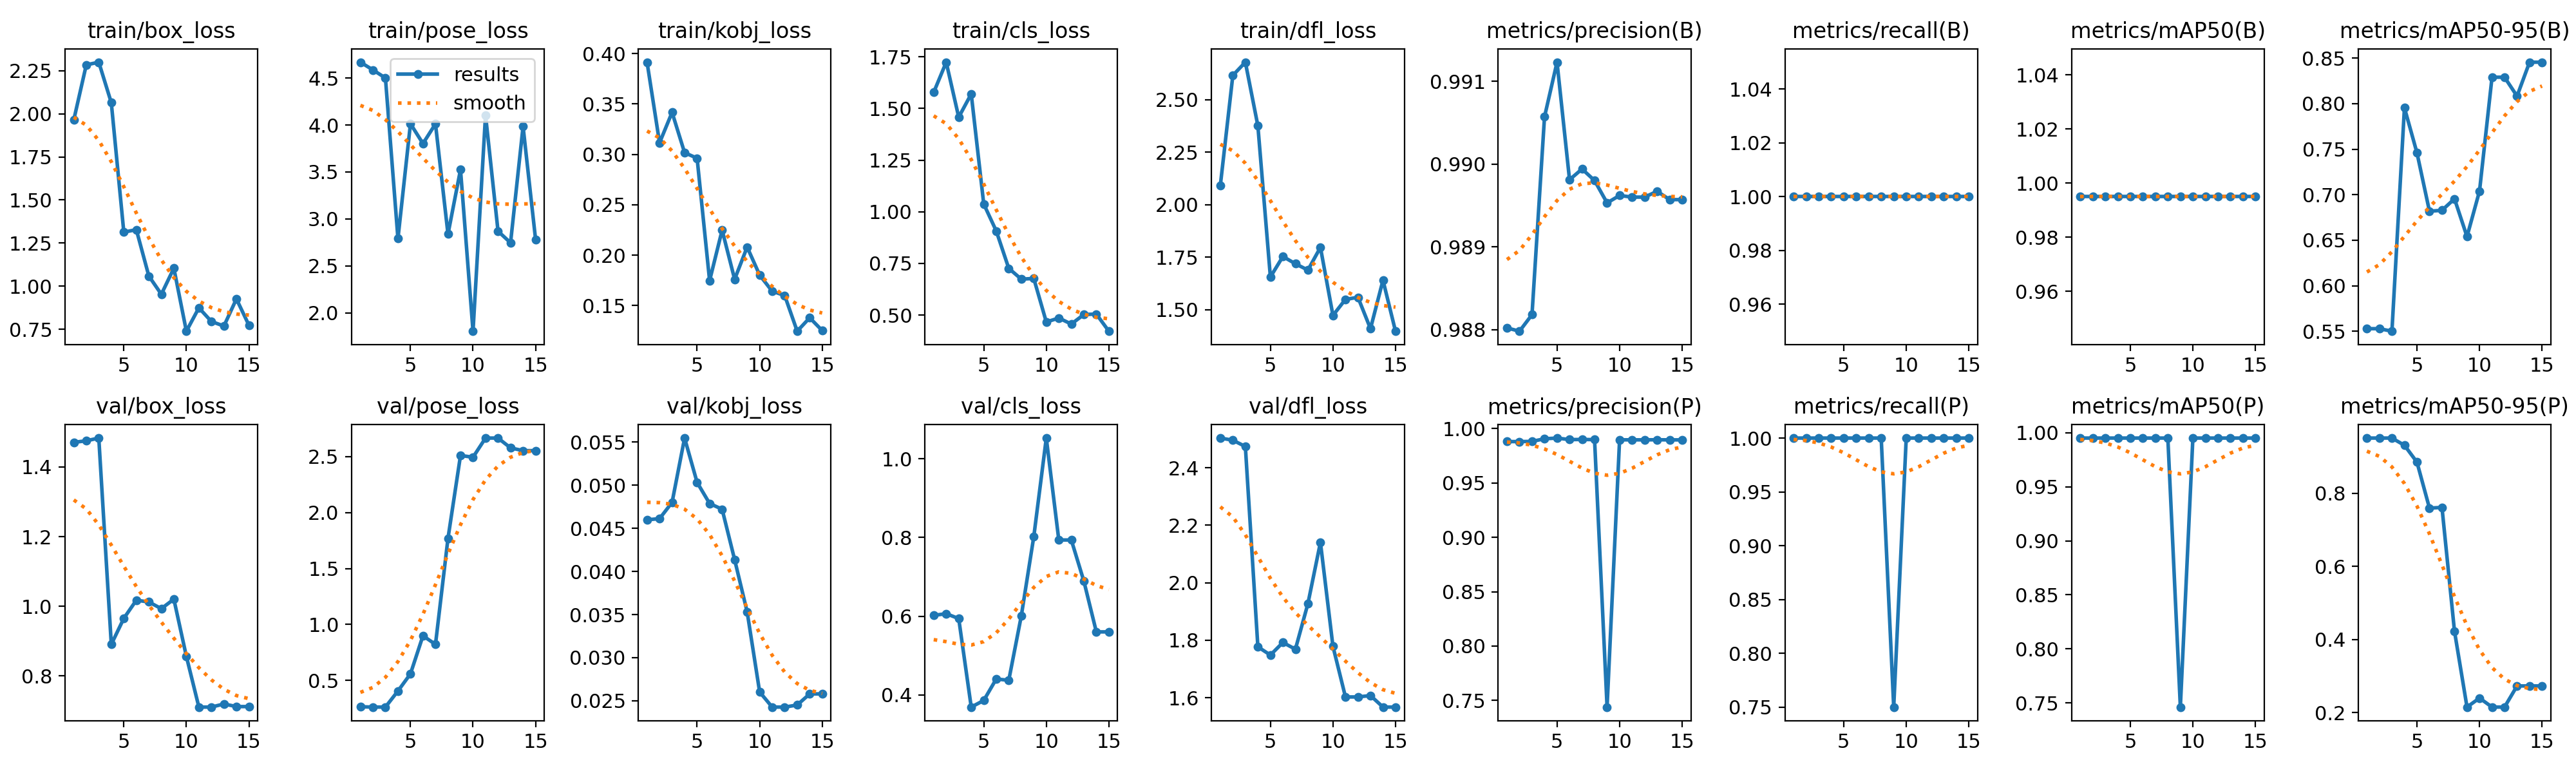

In [1]:
import os, zipfile, requests, shutil, yaml
from ultralytics import YOLO

# 1. 下载 Version 2 数据集
dataset_url = "https://app.roboflow.com/ds/Fq8fsILLGV?key=nJWdvG2s71"
extract_path = "/content/rehab_data_v2"

if os.path.exists(extract_path): shutil.rmtree(extract_path)
os.makedirs(extract_path)

print("🚀 正在下载 Version 2 数据集...")
r = requests.get(dataset_url, stream=True)
with open("/content/dataset_v2.zip", "wb") as f:
    for chunk in r.iter_content(8192): f.write(chunk)
with zipfile.ZipFile("/content/dataset_v2.zip", 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 2. 自动定位并修正 data.yaml 的路径
# Roboflow 解压后通常直接带一个 data.yaml
orig_yaml = os.path.join(extract_path, "data.yaml")

# 强制校准 YAML 里的路径，确保 YOLO 能精准找到图片
with open(orig_yaml, 'r') as f:
    config = yaml.safe_load(f)

# 更新路径为 Colab 绝对路径
config['path'] = extract_path
config['train'] = 'train/images'
config['val'] = 'valid/images'
if 'test' in config: config['test'] = 'test/images'

with open(orig_yaml, 'w') as f:
    yaml.dump(config, f)

print("✅ Version 2 路径校准完成！")

# 3. 启动训练
model = YOLO('yolov8n-pose.pt')
results = model.train(
    data=orig_yaml,
    epochs=15,
    imgsz=640,
    batch=8,
    name='rehab_pose_v2_final'
)

# 4. 展示结果
from IPython.display import Image, display
res_plot = 'runs/pose/rehab_pose_v2_final/results.png'
if os.path.exists(res_plot):
    display(Image(filename=res_plot))